Testing Learning Rate: 0.5...
Testing Learning Rate: 0.1...
Testing Learning Rate: 0.01...


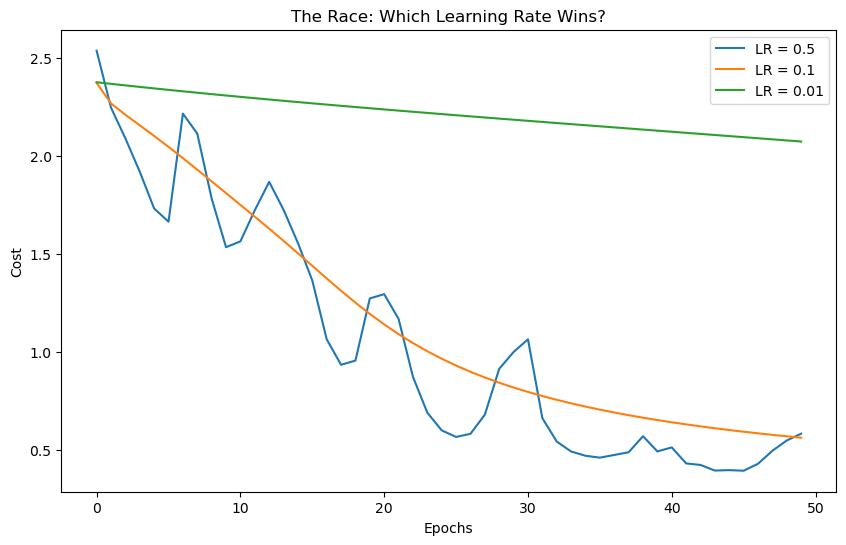

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt

# Step 1: Add the root directory to sys.path so we can import our engine
sys.path.append(os.path.abspath(os.path.join('..', 'Neural-Network-Scratch')))

from src.model import forward_propagation, compute_cost, backward_propagation, update_parameters
from src.layers import init_params
from utils.data_loader import load_mnist_data
from utils.preprocessing import prepare_data

# Step 2: Load and prep data once
X_raw, Y_raw = load_mnist_data('../Neural-Network-Scratch/data/mnist_train.csv')
X_train, Y_train = prepare_data(X_raw, Y_raw)

# Step 3: Run the experiment
lrs = [0.5, 0.1, 0.01]
plt.figure(figsize=(10, 6))

for lr in lrs:
    print(f"Testing Learning Rate: {lr}...")
    params = init_params([784, 64, 32, 10]) # Fresh start for every test
    costs = []
    
    for i in range(50): # 50 epochs is enough for a comparison
        AL, caches = forward_propagation(X_train, params)
        cost = compute_cost(AL, Y_train)
        grads = backward_propagation(AL, Y_train, caches)
        params = update_parameters(params, grads, lr)
        costs.append(cost)
    
    plt.plot(costs, label=f"LR = {lr}")

# Step 4: Finalize the Plot
plt.title("The Race: Which Learning Rate Wins?")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [4]:
import numpy as np

plt.figure(figsize=(10, 6))

def get_predictions(AL):
    """Returns the index of the highest probability."""
    return np.argmax(AL, axis=0)

def get_accuracy(predictions, Y):
    """Calculates the percentage of correct labels."""
    # Y is one-hot, so we need the index of the 1
    labels = np.argmax(Y, axis=0)
    return np.sum(predictions == labels) / labels.size

<Figure size 1000x600 with 0 Axes>